**IMPORTANTE**: Esta libreta lee una copia del conjunto de datos **Pasajeros de transporte público en Chicago**

El conjunto de datos está disponible para descargar en su sitio web oficial: https://data.cityofchicago.org/Transportation/CTA-Ridership-Daily-Boarding-Totals/6iiy-9s97

Así como en el repositorio GitHub que se ha habilitado para el curso.

In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras

In [2]:
# Read the dataset into a pandas dataframe structure
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
rides = pd.read_csv(url,
                    parse_dates=["service_date"])

rides.head() # show first 5 instances

,service_date,day_type,bus,rail_boardings,total_rides
0,2001-01-01,U,297192,126455,423647
1,2001-01-02,W,780827,501952,1282779
2,2001-01-03,W,824923,536432,1361355
3,2001-01-04,W,870021,550011,1420032
4,2001-01-05,W,890426,557917,1448343


Unos sencillos pasos de preprocesamiento. No necesitaremos la columna *total_rides*, que simplemente representa la suma de los viajes en autobús y tren por día. Además, sabemos que el conjunto de datos contiene duplicados, así que los eliminaremos.

Por último, y más importante, este es un conjunto de datos de **series temporales**, por lo que es fundamental asegurarnos de tener todos los datos ordenados -e incluso a ser posible, *indexados*- por fecha. Cada instancia está asociada a un día.

In [3]:
rides = rides.drop("total_rides", axis=1)
rides = rides.drop_duplicates()
rides = rides.sort_values("service_date").set_index("service_date")

In [4]:
# Now this is what our time series data looks like
rides.head()

,day_type,bus,rail_boardings
service_date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


Vamos a visualizar un fragmento de nuestra preciosa serie temporal, con la ayuda de la librería Matplotlib: escogeremos el primer trimestre de 2020.

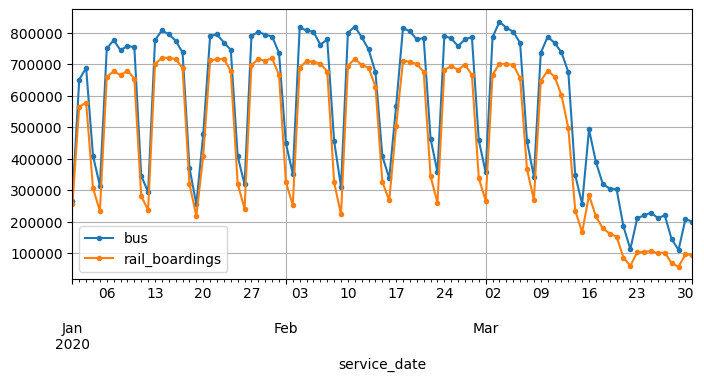

In [5]:
# But it is more beautiful to see with the aid of matplotlib library:
# Let's view the daily bus and rail rides during a two-month period
import matplotlib.pyplot as plt

rides["2020-01":"2020-03"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

## Entrenando una RNN muy simple: ¡tan solo una capa de una neurona!

Este modelo tan simple considera una serie temporal univariante: los instantes de tiempo *t* tienen asociado un solo atributo: pasajeros en tren por día. Dividimos esta serie temporal en conjuntos de entrenamiento, validación y prueba.

Para una mejor interpretación, escalamos los datos de la serie temporal dividiendo los valores entre 10^6 para representar "millones de pasajeros por día".

In [6]:
rail_train = rides["rail_boardings"]["2016-01":"2018-12"] / 1e6
rail_valid = rides["rail_boardings"]["2019-01":"2019-05"] / 1e6
rail_test = rides["rail_boardings"]["2019-06":] / 1e6

Es necesario convertir estos DataFrames en una estructura específica de Keras para modelar y utilizar correctamente series temporales:

In [7]:
train_ts = tf.keras.utils.timeseries_dataset_from_array(
    rail_train.to_numpy(),
    targets=rail_train[56:], # Consideraremos secuencias de entrenamiento de longitud 56, siendo el día siguiente a cada secuencia la etiqueta o predicción asociada
    sequence_length=56,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_ts = tf.keras.utils.timeseries_dataset_from_array(
    rail_valid.to_numpy(),
    targets=rail_valid[56:],
    sequence_length=56,
    batch_size=32
)
test_ts = tf.keras.utils.timeseries_dataset_from_array(
    rail_test.to_numpy(),
    targets=rail_valid[56:],
    sequence_length=56,
    batch_size=32
)

Para la forma de la capa de entrada, especificar:

* La longitud de la secuencia de entrada: cuántas entradas anteriores se utilizan para calcular la salida actual. *None* permite aceptar cualquier tamaño de secuencia de modo flexible.
* Número de atributos o variables a pronosticar: *1* para series temporales univariadas (p. ej., pronosticar solo viajes en autobús), o mayor que *1* para series temporales multivariadas (p. ej., pronosticar viajes en autobús y tren conjuntamente).

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Como novedad, en este ejemplo añadiremos un mecanismo de *early stopping* al proceso de entrenamiento que irá monitorizando cómo evoluciona la función de pérdida, es decir, la métrica MAE (error absoluto medio) a lo largo de las rondas (epochs).

MAE, MSE (error cuadrático medio) y MAPE (error porcentual absoluto medio) son las métricas más habituales para evaluar modelos de pronóstico de series temporales. En este caso, utilizaremos MAE.

In [9]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_mae", patience=3, restore_best_weights=True)
opt = tf.keras.optimizers.SGD(learning_rate=0.02)

# patience = 3 define tres epochs consecutivos para determinar si hay mejora o no
# Si no la hay, con restore_best_weights se revierte el estado de los pesos a aquellos que fueron los mejores de todo el proceso: no los últimos necesariamente

model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])

In [10]:
history = model.fit(train_ts, validation_data=valid_ts, epochs=500,
                        callbacks=[early_stopping_cb])

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0533 - mae: 0.2771 - val_loss: 0.0567 - val_mae: 0.2883
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0482 - mae: 0.2580 - val_loss: 0.0504 - val_mae: 0.2643
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0419 - mae: 0.2326 - val_loss: 0.0427 - val_mae: 0.2340
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0345 - mae: 0.2043 - val_loss: 0.0342 - val_mae: 0.2056
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0274 - mae: 0.1759 - val_loss: 0.0275 - val_mae: 0.1782
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0228 - mae: 0.1583 - val_loss: 0.0241 - val_mae: 0.1663
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0209 - mae: 0.1530 - val_loss: 0.0231 - val_mae: 0.1632
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0204 - mae: 0.1529 - val_loss: 0.0228 - val_mae: 0.1624
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

Con una arquitectura tan simple, es más que probable que el proceso de entrenamiento mencionado tome mucho menos de las 500 epochs especificadas, pudiendo efectuarse la parada temprana si la función de pérdida y el MAE se estabilizan.

Por último, evaluamos el error en los conjuntos de validación y prueba.

In [11]:
valid_loss, valid_mae = model.evaluate(valid_ts)
valid_mae * 1e6
# This is the mean average error on the validation data.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0204 - mae: 0.1540


153957.11362361908

In [12]:
test_loss, test_mae = model.evaluate(test_ts)
test_mae * 1e6
# This is the mean average error on the validation data.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0298 - mae: 0.1886


188643.6492204666

## Un modelo de pronóstico algo más complejo

2 capas, la primera de ellas posee 32 neuronas

In [13]:
model2 = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1)  # no activation function in output neuron
])
opt = tf.keras.optimizers.SGD(learning_rate=0.02)
# Re-initialize optimizer to prevent problems when training
model2.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])

In [14]:
history2 = model2.fit(train_ts, validation_data=valid_ts, epochs=500,
                        callbacks=[early_stopping_cb])

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0222 - mae: 0.1712 - val_loss: 0.0128 - val_mae: 0.1182
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0126 - mae: 0.1359 - val_loss: 0.0117 - val_mae: 0.1136
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0118 - mae: 0.1302 - val_loss: 0.0106 - val_mae: 0.1091
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0109 - mae: 0.1250 - val_loss: 0.0098 - val_mae: 0.1040
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0101 - mae: 0.1189 - val_loss: 0.0090 - val_mae: 0.0999
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0092 - mae: 0.1123 - val_loss: 0.0076 - val_mae: 0.0954
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0085 - mae: 0.1068 - val_loss: 0.0071 - val_mae: 0.0922
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0077 - mae: 0.0996 - val_loss: 0.0064 - val_mae: 0.0896
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - lo

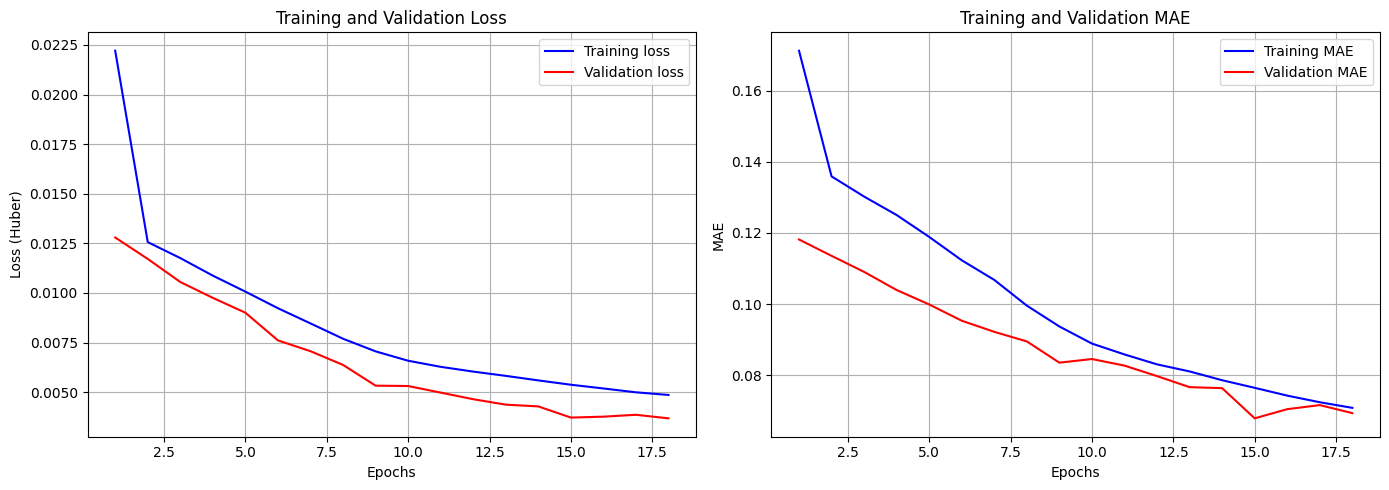

In [15]:
import matplotlib.pyplot as plt

# Get the training history data
loss = history2.history['loss']
val_loss = history2.history['val_loss']
mae = history2.history['mae']
val_mae = history2.history['val_mae']
epochs = range(1, len(loss) + 1)

# Create a single figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plotting Loss on the first subplot
ax1.plot(epochs, loss, 'b', label='Training loss')
ax1.plot(epochs, val_loss, 'r', label='Validation loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (Huber)')
ax1.legend()
ax1.grid(True)

# Plotting MAE on the second subplot
ax2.plot(epochs, mae, 'b', label='Training MAE')
ax2.plot(epochs, val_mae, 'r', label='Validation MAE')
ax2.set_title('Training and Validation MAE')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [16]:
valid_loss, valid_mae = model2.evaluate(valid_ts)
valid_mae * 1e6

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0037 - mae: 0.0680


67950.18166303635

In [17]:
test_loss, test_mae = model2.evaluate(test_ts)
test_mae * 1e6

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0432 - mae: 0.2458


245816.99073314667

## Construyamos ahora una RNN profunda

Dos capas ocultas con neuronas recurrentes.

In [18]:
deep_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])
opt = tf.keras.optimizers.SGD(learning_rate=0.02)
# Re-initialize optimizer to prevent problems when training
deep_model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])

In [19]:
deep_history = deep_model.fit(train_ts, validation_data=valid_ts, epochs=500,
                        callbacks=[early_stopping_cb])

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0362 - mae: 0.1843 - val_loss: 0.0077 - val_mae: 0.1003
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0090 - mae: 0.1045 - val_loss: 0.0050 - val_mae: 0.0792
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0074 - mae: 0.0917 - val_loss: 0.0052 - val_mae: 0.0815


In [20]:
valid_loss, valid_mae = deep_model.evaluate(valid_ts)
valid_mae * 1e6

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0077 - mae: 0.1003


100264.11712169647

In [21]:
test_loss, test_mae = deep_model.evaluate(test_ts)
test_mae * 1e6

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0367 - mae: 0.2222


222223.81830215454

Ahora te estarás preguntando: ¿por qué el rendimiento en el conjunto de prueba es mucho peor que en el conjunto de validación?

Recordemos las instrucciones donde se realizó la división:

```
rail_train = rides["rail_boardings"]["2016-01":"2018-12"] / 1e6
rail_valid = rides["rail_boardings"]["2019-01":"2019-05"] / 1e6
rail_test = rides["rail_boardings"]["2019-06":] / 1e6
```
Hemos dividido los datos en tres ventanas temporales consecutivas. Los modelos se entrenaron con datos entre 2016 y 2018. El conjunto de validación abarca los cinco meses posteriores a 2018, por lo que pronosticar con este conjunto es como hacer predicciones a corto plazo; Mientras que el conjunto de pruebas abarca junio de 2019, pronosticar aquí es como hacer predicciones a largo plazo. Parece lógico que pronosticar el futuro muy lejano sea menos preciso que pronosticar el futuro cercano, más aún cuando buena parte de los datos posteriores a 2019 sufrieron enormes cambios debido al COVID.


**EJERCICIO PROPUESTO**

* Toca investigar y probar con diferentes "ventanas temporales" para particionar tu dataset en conjuntos de entrenamiento, validación, y pruebas. Opcionalmente, prueba a definir tu propia arquitectura de RNN y ajustar otros hiperparámetros a tu elección, por ejemplo el learning_rate u otros asociados al entrenamiento.

¿Conseguirás reducir un poco ese "abismo" entre el error cometido en el conjunto de validación y el del conjunto de prueba?